# 节点的并行
- 通过定义Edge来决定节点的运行顺序
- 并行节点返回的值必须有`Reducer`，否则在合并时，拿到多个并行结果LangGraph并不知道用哪个值
    > InvalidUpdateError: At key 'cur_id': Can receive only one value per step. Use an Annotated key to handle multiple values.

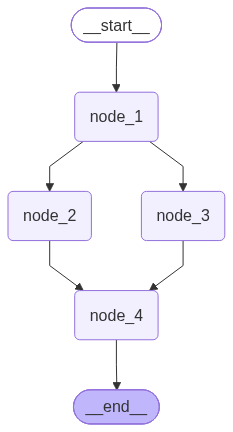

{'logs': ['start', 'node_1执行完毕', 'node_2执行完毕', 'node_3执行完毕', 'node_4执行完毕'], 'cur_id': 'startnode_1node_2node_3node_4'}


In [4]:
from IPython.core.display import Image, display_png
from langgraph.constants import START
from langgraph.constants import END
from langgraph.graph import StateGraph
from operator import add
from typing import Annotated, TypedDict


class StateSchema(TypedDict):
    logs: Annotated[list[str], add]
    cur_id: Annotated[str, add]

graph_builder = StateGraph(state_schema=StateSchema)

def node_1(state: StateSchema) -> StateSchema:
    return {
        "logs": ['node_1执行完毕'],
        "cur_id": "node_1"
    }

def node_2(state: StateSchema) -> StateSchema:
    return {
        "logs": ['node_2执行完毕'],
        "cur_id": "node_2"
    }

def node_3(state: StateSchema) -> StateSchema:
    return {
        "logs": ['node_3执行完毕'],
        "cur_id": "node_3"
    }

def node_4(state: StateSchema) -> StateSchema:
    return {
        "logs": ['node_4执行完毕'],
        "cur_id": "node_4"
    }

graph_builder.add_node("node_1", node_1)
graph_builder.add_node("node_2", node_2)
graph_builder.add_node("node_3", node_3)
graph_builder.add_node("node_4", node_4)

graph_builder.add_edge(START, "node_1")
graph_builder.add_edge("node_1", "node_2")
graph_builder.add_edge("node_1", "node_3")
graph_builder.add_edge("node_2", "node_4")
graph_builder.add_edge("node_3", "node_4")
graph_builder.add_edge("node_4", END)

graph = graph_builder.compile()
graph_result = graph.invoke({
    "logs": ['start'],
    "cur_id": "start"
})

png_bytes = graph.get_graph().draw_mermaid_png()
png = Image(png_bytes)
display_png(png)

print(graph_result)

